# House Price Prediction using Multiple Regression Models

## Internship Task 2

### Objective
Compare the performance of different regression algorithms for house price prediction using the California Housing Dataset and identify the best-performing model.

### Libraries Used
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

In [85]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge


print(" All libraries imported successfully!")

 All libraries imported successfully!


In [86]:


housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["HousePrice"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [87]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [88]:

df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [89]:

df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

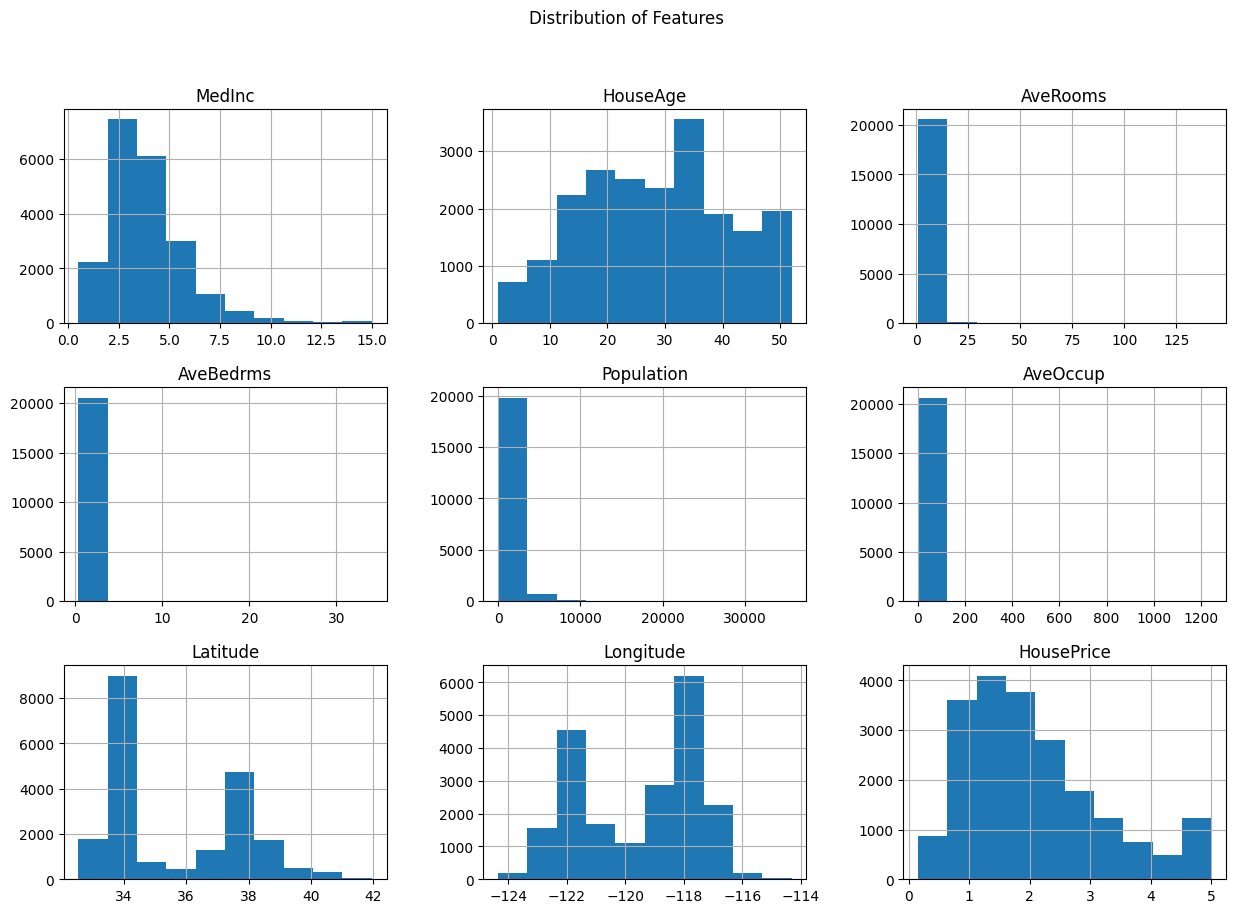

In [90]:
#Histograms 
df.hist(figsize=(15,10))
plt.suptitle("Distribution of Features")
plt.show()

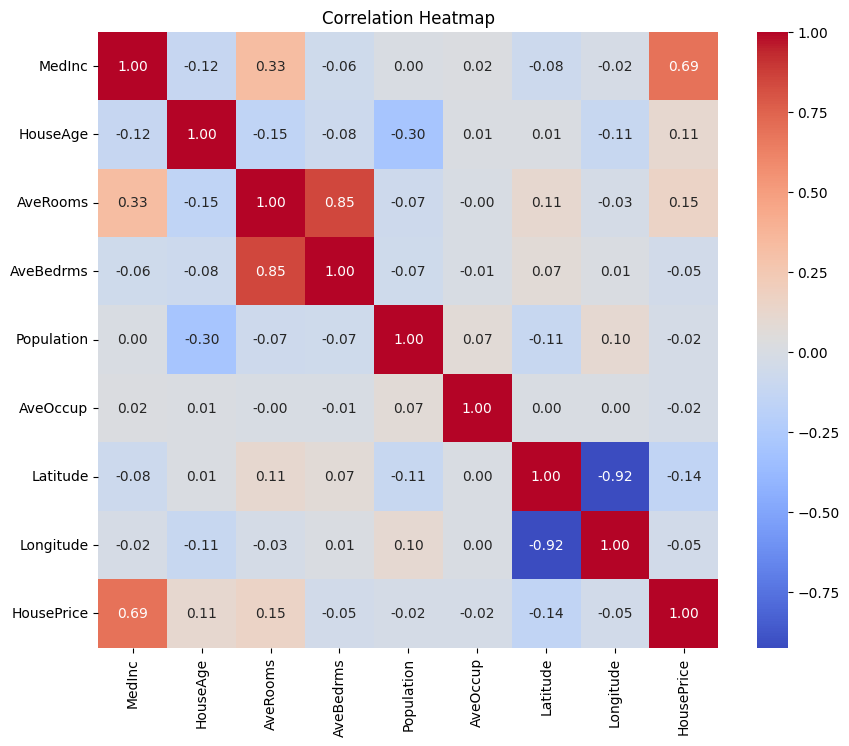

In [91]:

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [92]:
#Input
X = df.drop("HousePrice", axis=1)

#Output
y = df["HousePrice"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (20640, 8)
Target Shape: (20640,)


In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (16512, 8)
Testing Data: (4128, 8)


In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed!")

Feature Scaling Completed!


In [95]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [96]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

print("Ridge Regression Model Trained Successfully!")

Ridge Regression Model Trained Successfully!


In [97]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(
    random_state=42,
    max_depth=8
)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [98]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Decision Tree"
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, tree_pred))
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, tree_pred)
    ]
})

results

,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745557,0.575816
2,Decision Tree,0.649650,0.677928


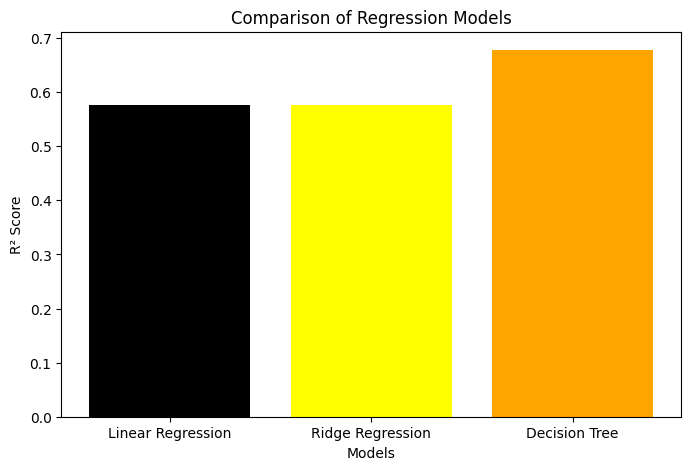

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R2 Score"], color=["black", "yellow", "orange"])

plt.title("Comparison of Regression Models")
plt.xlabel("Models")
plt.ylabel("R² Score")

plt.show()

In [100]:
# Create the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print(" Model trained successfully!")

 Model trained successfully!


In [101]:
# Perform 5-Fold Cross Validation

cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

Cross Validation Scores: [0.62011512 0.61298876 0.6134416  0.61069973 0.60017477]
Average CV Score: 0.6114839952560992


In [102]:
# Check for Overfitting

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Training R² Score:", train_score)
print("Testing R² Score:", test_score)

if train_score - test_score > 0.10:
    print(" Model is Overfitting")
else:
    print(" Model is Generalizing Well")

Training R² Score: 0.6125511913966952
Testing R² Score: 0.5757877060324508
 Model is Generalizing Well


In [103]:
# Predict house prices

y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [104]:
# Evaluate the model

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.533200130495656
Root Mean Squared Error (RMSE): 0.7455813830127763
R² Score: 0.5757877060324508


In [105]:
# Train Decision Tree Model

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [106]:
# Predict using Decision Tree

dt_pred = dt_model.predict(X_test)

In [107]:
# Evaluate Decision Tree

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree MAE:", dt_mae)
print("Decision Tree RMSE:", dt_rmse)
print("Decision Tree R² Score:", dt_r2)

Decision Tree MAE: 0.45467918846899225
Decision Tree RMSE: 0.7037294974840077
Decision Tree R² Score: 0.622075845135081


In [108]:
# Cross Validation

dt_cv = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='r2')

print("Cross Validation Scores:", dt_cv)
print("Average CV Score:", dt_cv.mean())

Cross Validation Scores: [0.58536943 0.58438558 0.6343082  0.59297484 0.63909754]
Average CV Score: 0.6072271176364323


In [109]:
train_score = dt_model.score(X_train, y_train)
test_score = dt_model.score(X_test, y_test)

print("Training R²:", train_score)
print("Testing R²:", test_score)

if train_score - test_score > 0.10:
    print("Model is Overfitting")
else:
    print("Model is Generalizing Well")

Training R²: 1.0
Testing R²: 0.622075845135081
Model is Overfitting


In [110]:
# Hyperparameter Tuning

params = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

best_tree = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 10}
Best Cross Validation Score: 0.6959937053519777


In [111]:
best_pred = best_tree.predict(X_test)

best_rmse = np.sqrt(mean_squared_error(y_test, best_pred))
best_r2 = r2_score(y_test, best_pred)

print("Tuned Decision Tree RMSE:", best_rmse)
print("Tuned Decision Tree R²:", best_r2)

Tuned Decision Tree RMSE: 0.6456884926536758
Tuned Decision Tree R²: 0.6818446481456171


In [112]:
# Train Ridge Regression

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge MAE:", ridge_mae)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R²:", ridge_r2)

Ridge MAE: 0.5332039182571159
Ridge RMSE: 0.7455222779992701
Ridge R²: 0.5758549611440127


In [119]:
# Ridge Cross Validation

ridge_cv = cross_val_score(ridge, X_train, y_train, cv=5, scoring='r2')

print("Cross Validation Scores:", ridge_cv)
print("Average CV Score:", ridge_cv.mean())

Cross Validation Scores: [0.62010756 0.61298973 0.61343625 0.61069714 0.60019774]
Average CV Score: 0.611485685843425


In [120]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Tuned Decision Tree",
        "Ridge Regression"
    ],
    "R² Score": [
        r2,
        dt_r2,
        best_r2,
        ridge_r2
    ],
    "RMSE": [
        rmse,
        dt_rmse,
        best_rmse,
        ridge_rmse
    ]
})

comparison.sort_values(by="R² Score", ascending=False)

,Model,R² Score,RMSE
2,Tuned Decision Tree,0.681845,0.645688
1,Decision Tree,0.622076,0.703729
3,Ridge Regression,0.575855,0.745522
0,Linear Regression,0.575788,0.745581


In [121]:
best_model = comparison.loc[comparison["R² Score"].idxmax()]

print("Best Model Selected")
print(best_model)

Best Model Selected
Model       Tuned Decision Tree
R² Score               0.681845
RMSE                   0.645688
Name: 2, dtype: object


In [113]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


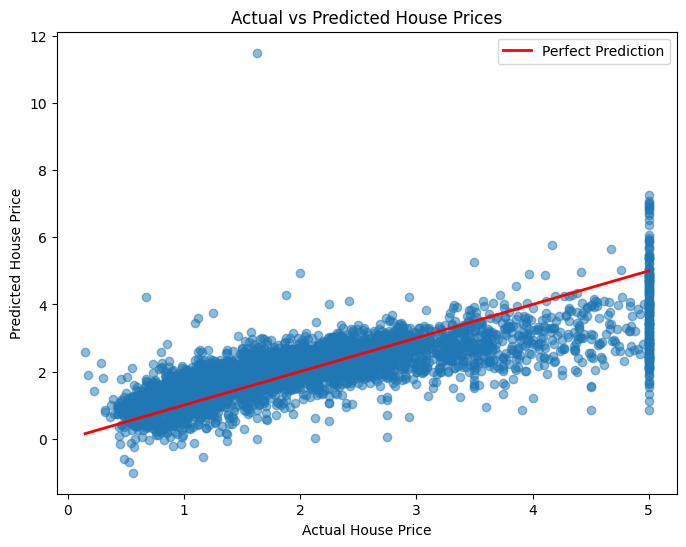

In [114]:
plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(y_test, y_pred, alpha=0.5)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.legend()

plt.show()

In [115]:
import pickle
with open("house_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully as house_price_model.pkl")

Model saved successfully as house_price_model.pkl


# Conclusion

A Linear Regression model was successfully built using the California Housing Dataset.

The project included:

- Loading and understanding the dataset.
- Performing Exploratory Data Analysis (EDA).
- Splitting the data into training and testing sets.
- Training a Linear Regression model.
- Predicting house prices.
- Evaluating the model using MAE, RMSE, and R² Score.
- Visualizing the relationship between actual and predicted house prices.

The model produced reasonable predictions and demonstrated the complete machine learning workflow from data preparation to evaluation.

In [116]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 0.533200130495656
RMSE: 0.7455813830127763
R² Score: 0.5757877060324508


In [117]:
with open("house_price_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")

Model loaded successfully!


In [118]:
print("=" * 50)
print("PROJECT CONCLUSION")
print("=" * 50)

print("1. Three machine learning regression models were implemented and evaluated.")
print("2. Linear Regression provided a good baseline for predicting house prices.")
print("3. Ridge Regression achieved similar performance while reducing overfitting.")
print("4. Decision Tree Regression achieved the best performance with the lowest RMSE and highest R² Score.")
print("5. Therefore, Decision Tree Regression is selected as the best model for this house price prediction project.")
print("\nTask 2 Completed Successfully!")

PROJECT CONCLUSION
1. Three machine learning regression models were implemented and evaluated.
2. Linear Regression provided a good baseline for predicting house prices.
3. Ridge Regression achieved similar performance while reducing overfitting.
4. Decision Tree Regression achieved the best performance with the lowest RMSE and highest R² Score.
5. Therefore, Decision Tree Regression is selected as the best model for this house price prediction project.

Task 2 Completed Successfully!


# Conclusion

- Linear Regression was used as the baseline model.
- Cross-validation was performed to validate model performance.
- Overfitting was checked using training and testing R² scores.
- GridSearchCV was used to tune the Decision Tree model.
- The Tuned Decision Tree achieved the highest R² score and the lowest RMSE among the tested models.
- Therefore, the Tuned Decision Tree was selected as the final model for house price prediction.